In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('../../cp/results_base4_enhsp.csv')
df

,config,num_trains,num_expansions,cost,makespan_pp,search_time
0,6,3,17609,-1,104,-1
1,6,4,6084,12,126,290
2,6,5,2948,15,187,290
3,6,6,337515,24,175,90
4,6,7,1290,21,253,180
5,6,8,20443,27,251,150
6,7,3,19805,-1,130,10
7,7,4,78,60,168,290
8,8,3,19601,-1,93,10
9,9,3,156880,-1,84,90


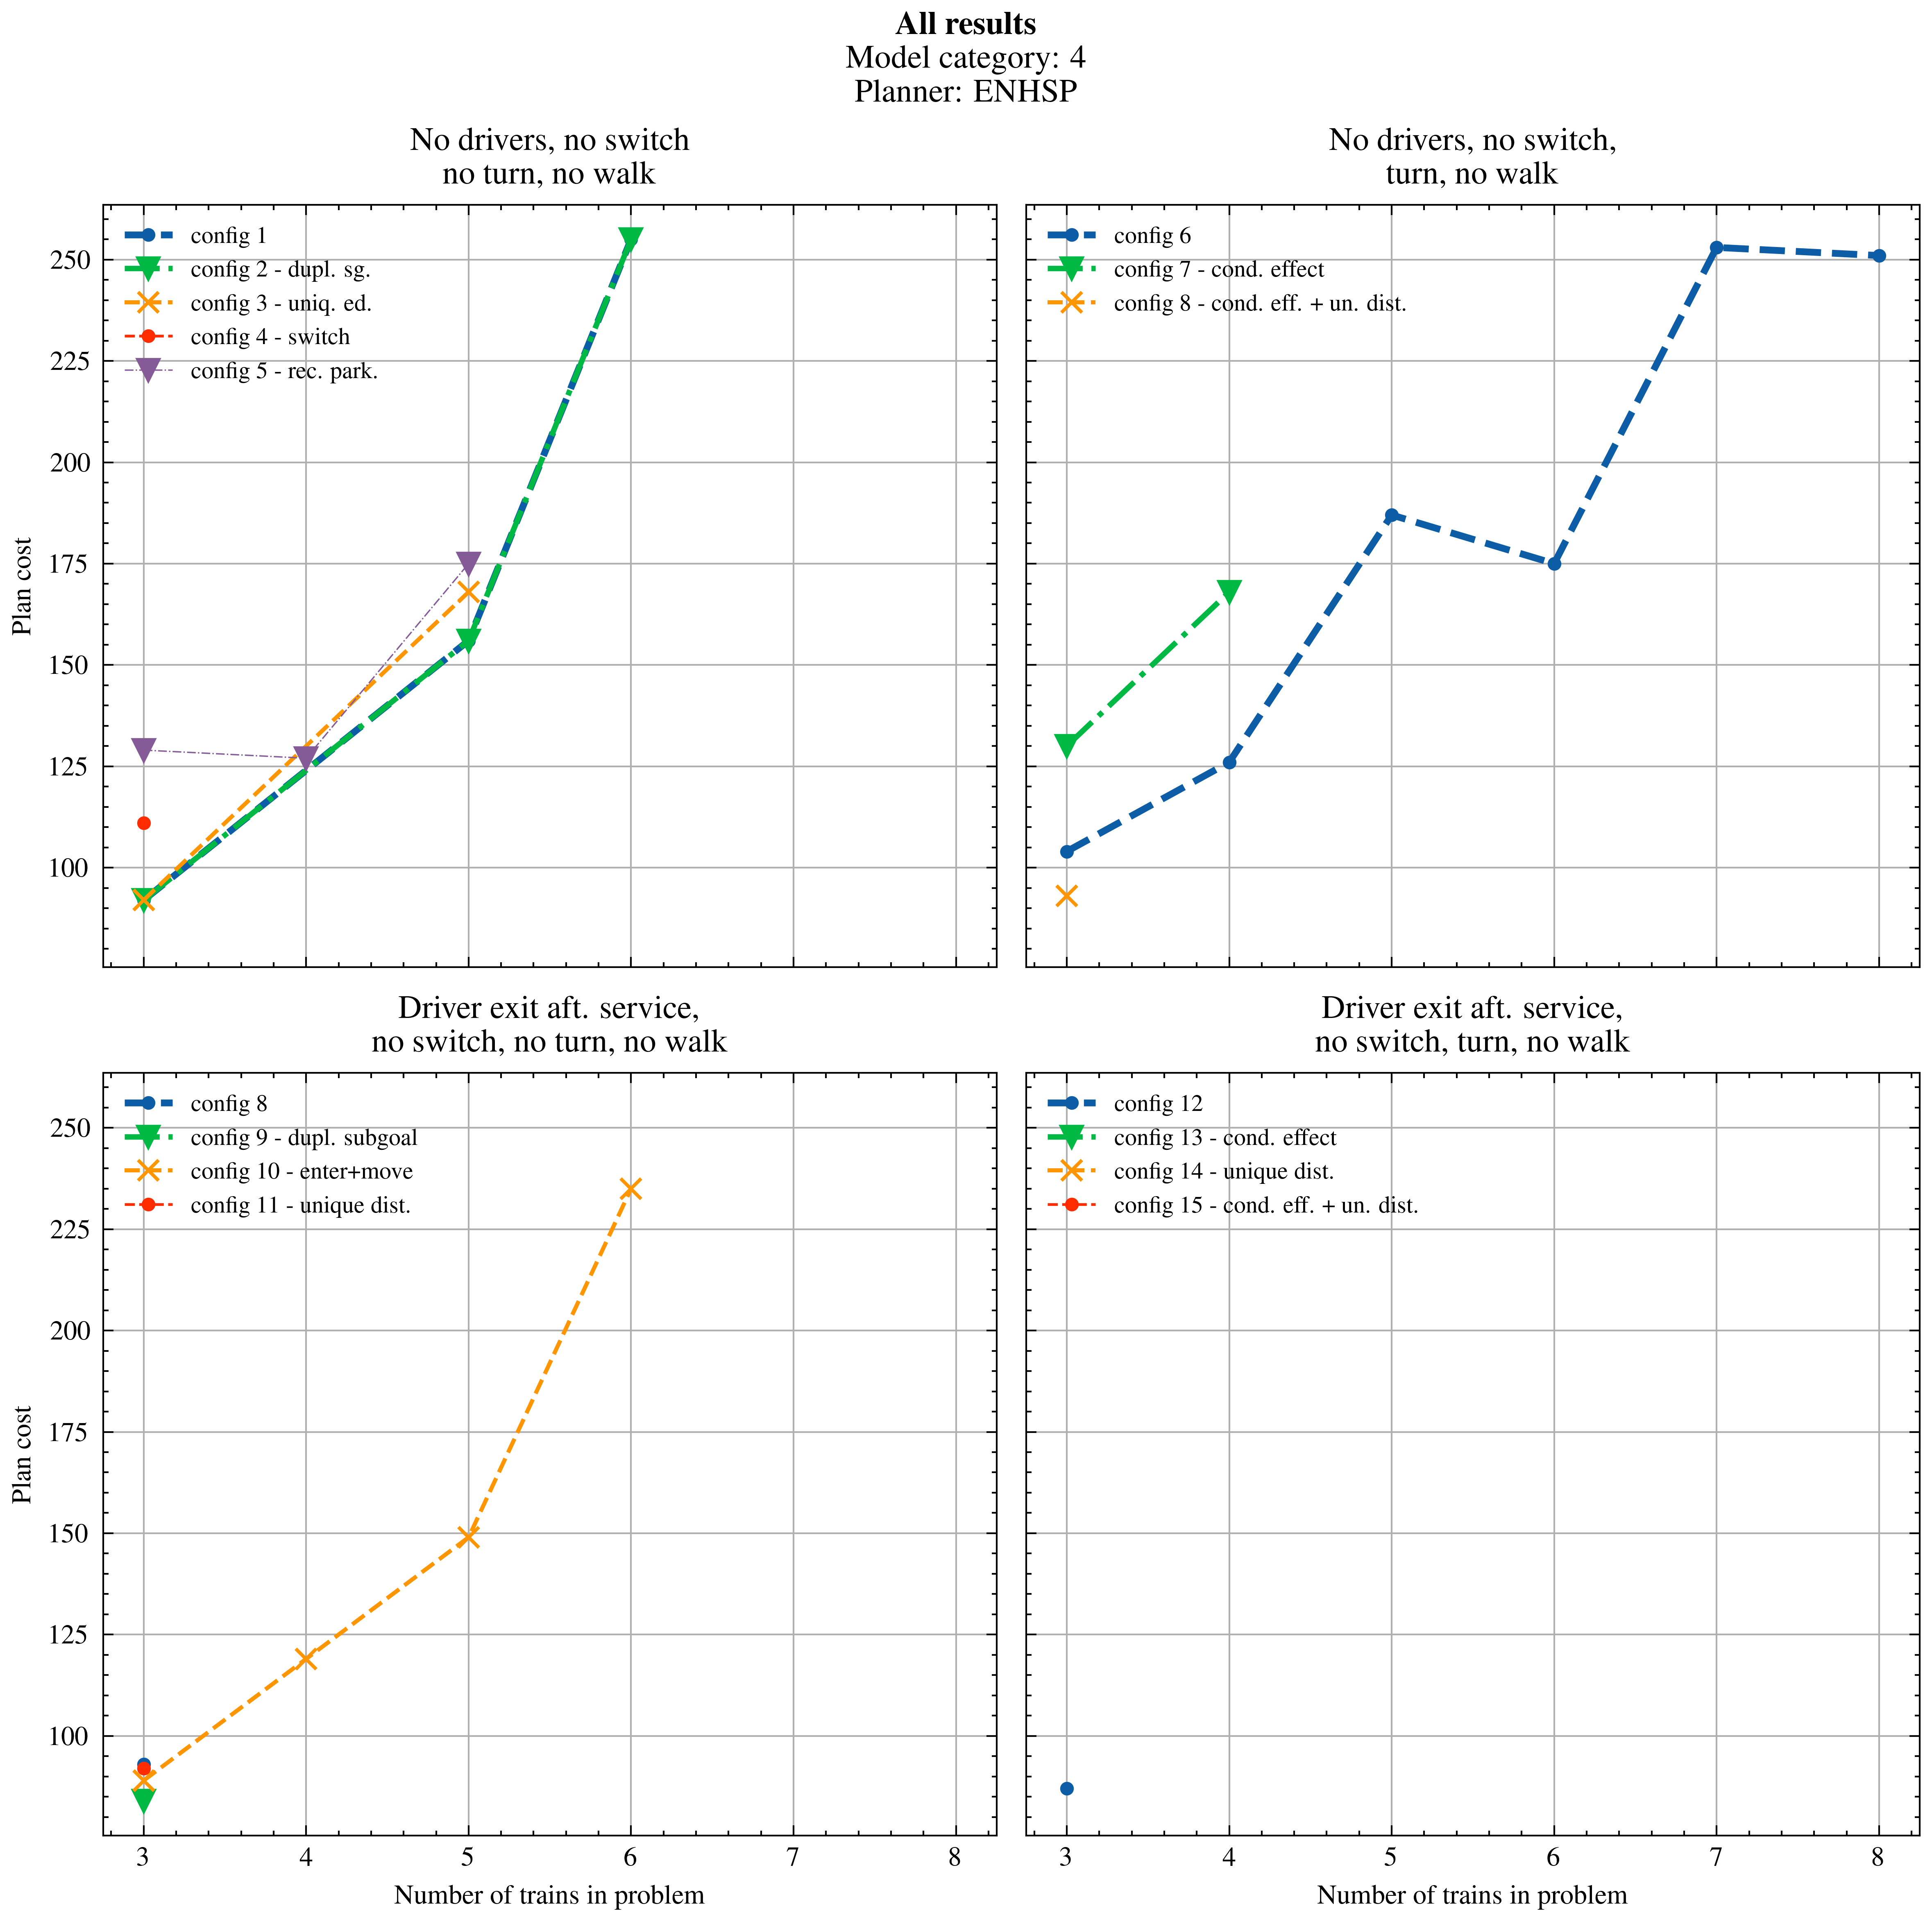

In [3]:
plt.style.use(['ieee', 'science'])

groups = [[1,2,3,4,5],[6,7,8],[8,9,10,11],[12,13,14,15]]
labels = [['', '- dupl. sg.', '- uniq. ed.', '- switch', '- rec. park.'],
          ['', '- cond. effect', '- cond. eff. + un. dist.' ],
          ['', '- dupl. subgoal', '- enter+move', '- unique dist.'],
          ['', '- cond. effect', '- unique dist.', '- cond. eff. + un. dist.'],
          ]
group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(2,2, figsize=(8,8), sharey=True, sharex=True)
ax = ax.flatten()
fig.suptitle(r"""\textbf{All results}
             Model category: 4
             Planner: ENHSP""")

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        if j % 3 == 0:
            dots = '.--'
        elif j % 3 == 1:
            dots = 'v-.'
        else:
            dots = 'x--'
        ax[i].plot(group_x[i][j], group_y[i][j], dots, label=f'config {groups[i][j]} {labels[i][j]}', linewidth=2-0.4*j)
        ax[i].legend(loc='upper left', fontsize=7)
        ax[i].grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

ax[0].set_ylabel('Plan cost')
ax[2].set_ylabel('Plan cost')
ax[2].set_xlabel('Number of trains in problem')
ax[3].set_xlabel('Number of trains in problem')
# ax[5].set_xlabel('Number of trains in problem')


ax[0].set_title('No drivers, no switch\n no turn, no walk')
ax[1].set_title('No drivers, no switch,\n turn, no walk')
ax[2].set_title('Driver exit aft. service,\n no switch, no turn, no walk')
ax[3].set_title('Driver exit aft. service,\n no switch, turn, no walk')
# ax[4].set_title('Driver exit aft. service,\n no switch, no turn, walk')
# ax[5].set_title('Driver exit aft. service,\n switch, no turn, no walk')


fig.tight_layout()
fig.savefig('enhsp_base4_makespans.png')


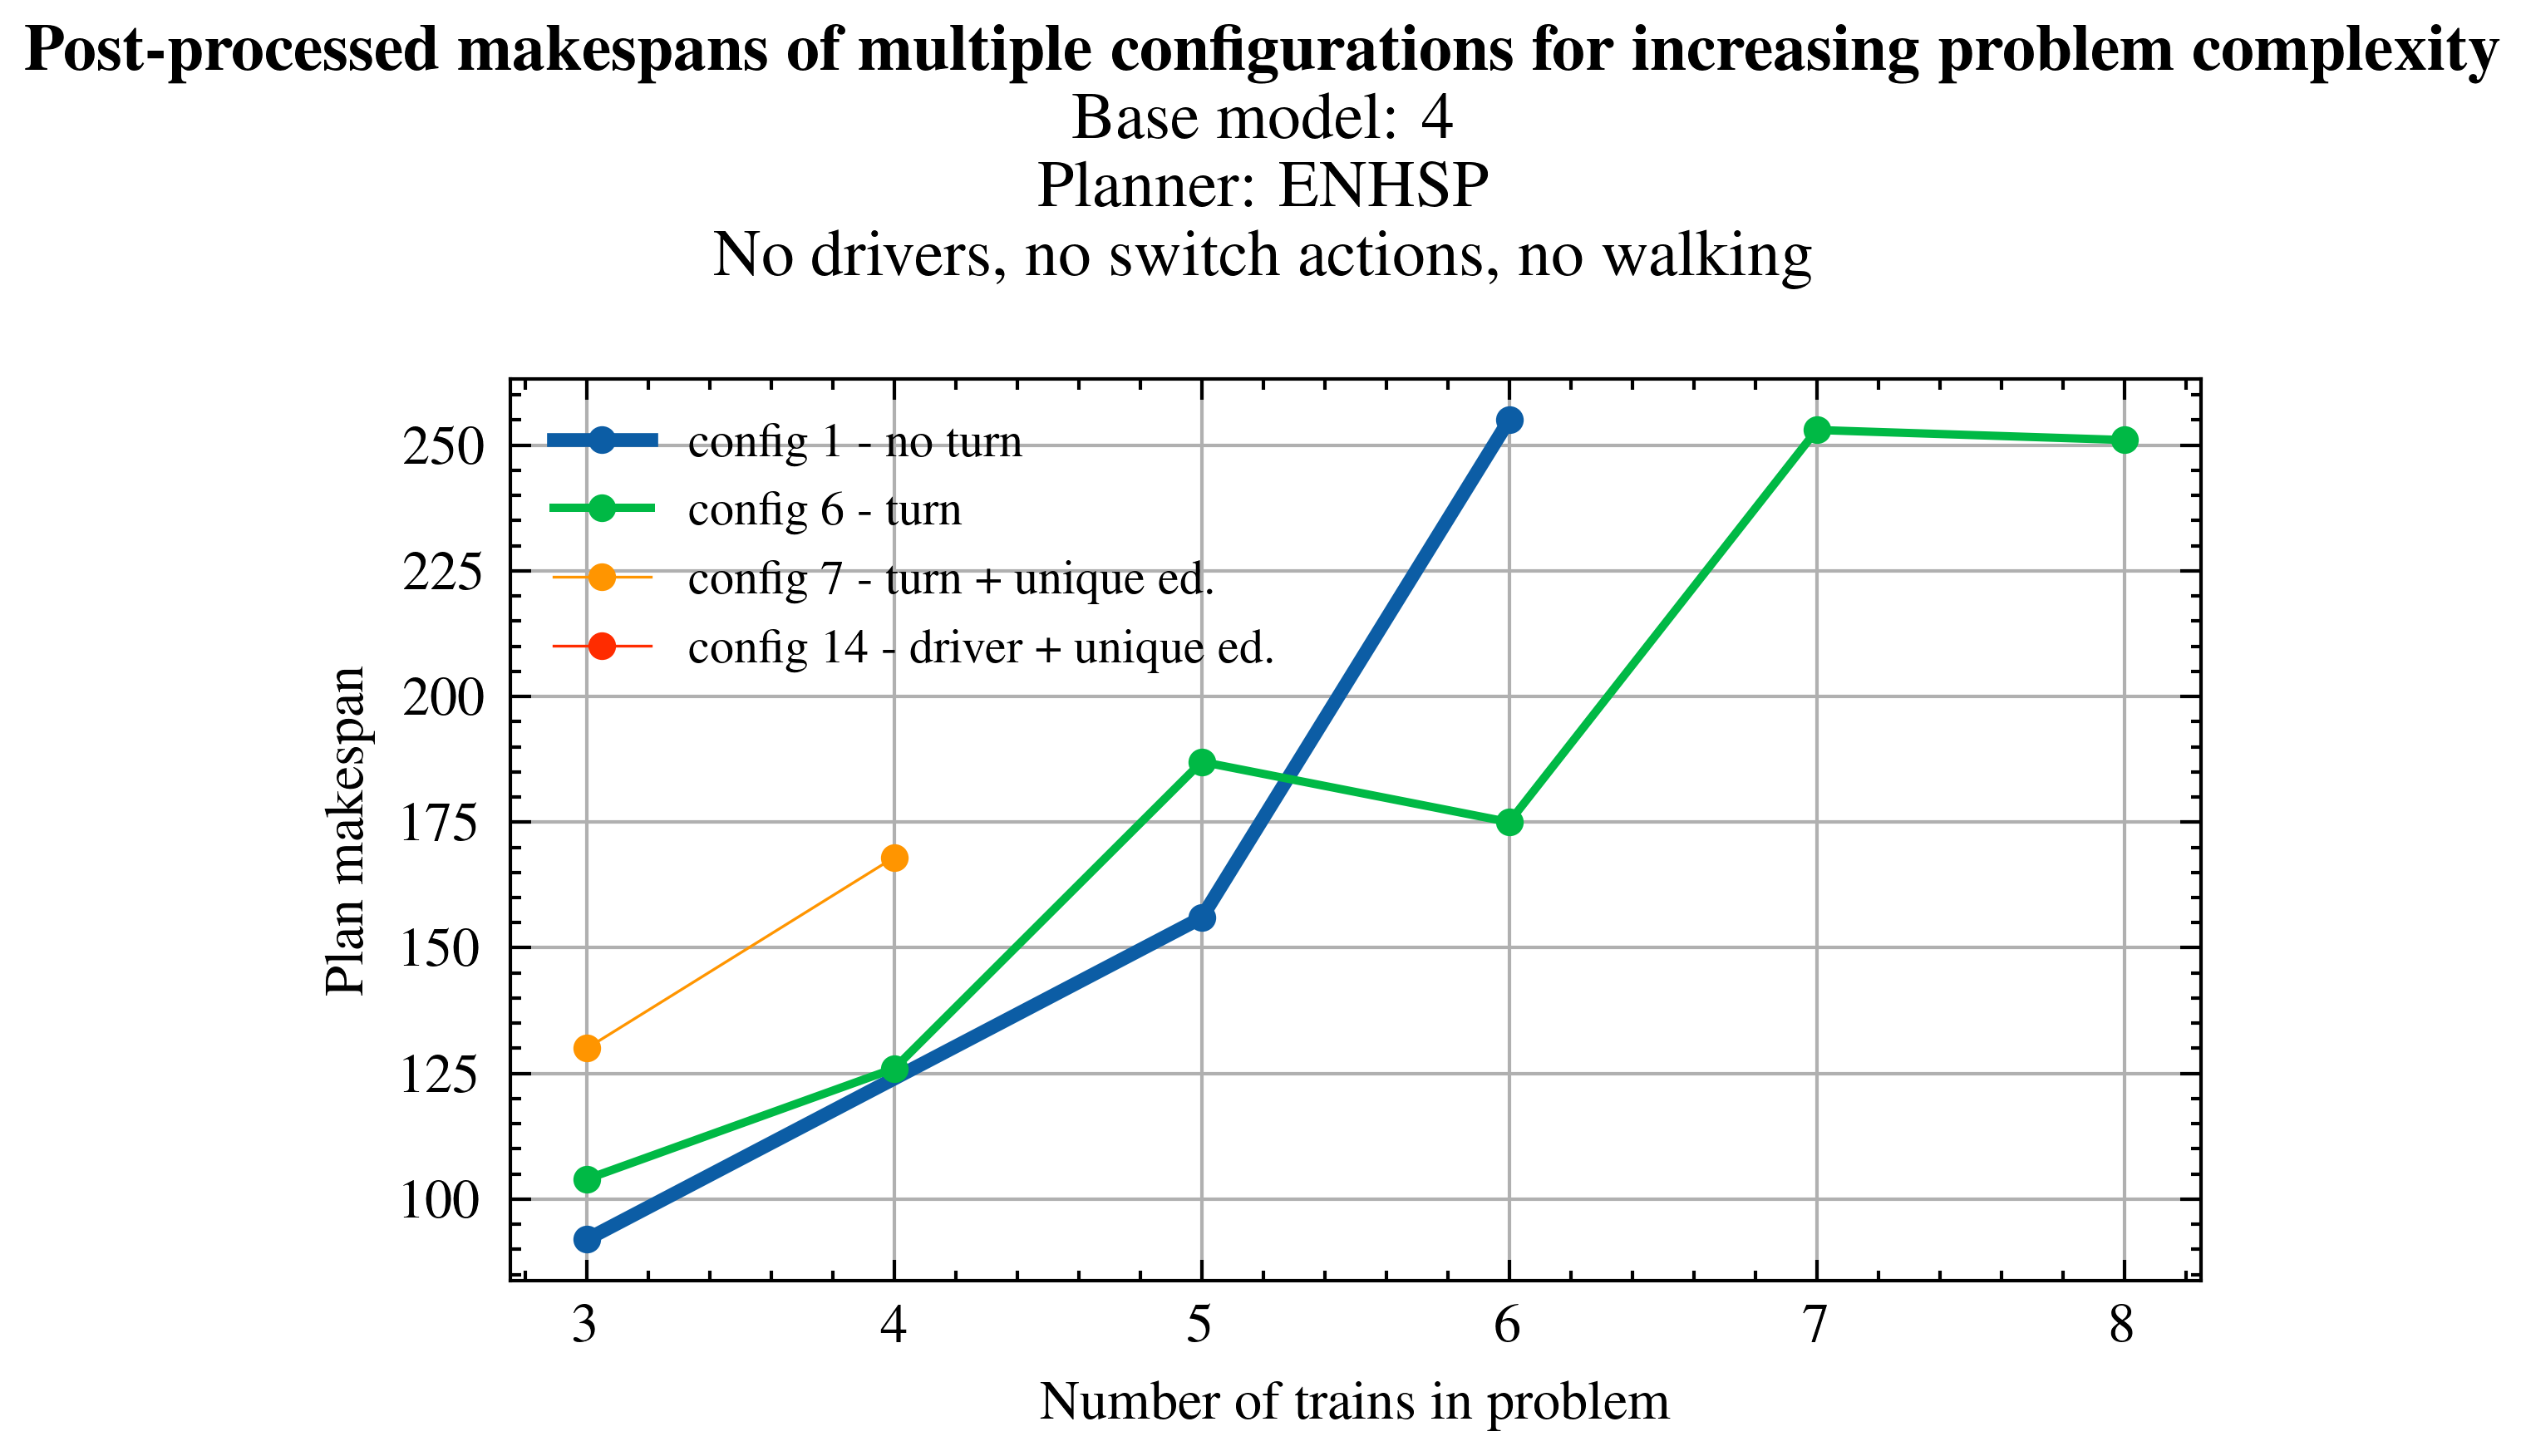

In [4]:
plt.style.use(['ieee', 'science'])

groups = [[1,6, 7, 14]]
labels = [
    ['- no turn', '- turn', '- turn + unique ed.', '- driver + unique ed.']
]

group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(1,1, figsize=(4,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{Post-processed makespans of multiple configurations for increasing problem complexity}
             Base model: 4
             Planner: ENHSP
             No drivers, no switch actions, no walking""")

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        ax.plot(group_x[i][j], group_y[i][j], '.-', label=f'config {groups[i][j]} {labels[i][j]}', linewidth=2-0.8*j)
        ax.legend(loc='upper left', fontsize=7)
        ax.grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Number of trains in problem')

fig.tight_layout()
fig.savefig('enhsp_base4_makespans_pp.png')
